# Mental Health Risk Prediction

Mental health is a critical aspect of overall well-being, and early detection of potential risks can help in timely intervention.  
This project applies **machine learning and deep learning techniques** to predict mental health risks by analyzing stress-related features.  

### Objectives
- Preprocess and analyze mental health–related datasets  
- Train and evaluate models using both ML and DL approaches  
- Deploy a user-friendly application for predictions  

### Significance
By leveraging data-driven insights and advanced deep learning methods, this project contributes toward raising awareness and supporting preventive measures in mental health care.

## Importing Required Libraries

In [280]:
# For data manipulation
import pandas as pd
import numpy as np

# For Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ML Models
from sklearn.tree import DecisionTreeClassifier

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Import Warnings
import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [281]:
# Loading CSV dataset using pandas

df = pd.read_csv("C:/Users/MADHUSUDAN MISHRA/Downloads/archive (5)/Mental Health Dataset.csv")
df.head()  # Displays first 5 rows to verify

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


### Dataset Overview

In [282]:
print(df.info()) # Dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-null  object
 14  Social_Weakness     

In [283]:
print("Dataset shape:", df.shape) # Rows x Columns

Dataset shape: (292364, 17)


In [284]:
df.describe() # Summary statistics for numeric columns

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
count,292364,292364,292364,292364,287162,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364
unique,580,2,35,5,2,2,2,5,3,3,3,3,2,3,3,3,3
top,8/27/2014 11:43,Male,United States,Housewife,No,No,Yes,1-14 days,Maybe,Yes,No,Medium,No,No,Maybe,No,No
freq,2384,239850,171308,66351,257994,176832,147606,63548,99985,109523,104018,101064,154328,105843,103393,232166,118886


In [285]:
df.isnull().sum() # Checking for missing values

Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_Struggles              0
Work_Interest                 0
Social_Weakness               0
mental_health_interview       0
care_options                  0
dtype: int64

### Dropping Unnecessary Columns

In [286]:
df.drop("Timestamp", axis=1, inplace=True)

df.drop("Country",axis=1,inplace=True)

In [287]:
df.head() 

,Gender,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,Female,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,Female,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,Female,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,Female,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,Female,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


### Filling Missing Values

In [288]:
# Fill missing categorical values with mode
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)

# Verify
print(df.isnull().sum())

Gender                     0
Occupation                 0
self_employed              0
family_history             0
treatment                  0
Days_Indoors               0
Growing_Stress             0
Changes_Habits             0
Mental_Health_History      0
Mood_Swings                0
Coping_Struggles           0
Work_Interest              0
Social_Weakness            0
mental_health_interview    0
care_options               0
dtype: int64


In [289]:
df.head()

,Gender,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,Female,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,Female,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,Female,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,Female,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,Female,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


### Handling Duplicates

In [290]:
df.duplicated().sum()

np.int64(260570)

In [291]:
# Remove duplicate rows
df = df.drop_duplicates()

# Verify again
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (31794, 15)


In [292]:
df.sample(5)

,Gender,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
109,Female,Corporate,No,Yes,No,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
16701,Female,Student,No,Yes,Yes,More than 2 months,Yes,Yes,No,High,No,No,No,Maybe,Yes
135227,Male,Business,Yes,No,No,15-30 days,Maybe,Yes,No,High,Yes,No,Maybe,Maybe,Yes
229638,Male,Business,No,No,No,1-14 days,Maybe,Maybe,No,Medium,Yes,No,No,Maybe,No
291767,Male,Business,No,No,Yes,15-30 days,No,Maybe,No,Low,Yes,No,Maybe,Maybe,Yes


### Checking Distribution

In [293]:
df['Growing_Stress'].value_counts()

Growing_Stress
Yes      11144
Maybe    10655
No        9995
Name: count, dtype: int64

In [294]:
df['Occupation'].value_counts()

Occupation
Housewife    7199
Student      6807
Corporate    6427
Others       5835
Business     5526
Name: count, dtype: int64

In [295]:
df['Days_Indoors'].value_counts()

Days_Indoors
1-14 days             6777
31-60 days            6567
Go out Every day      6419
More than 2 months    6110
15-30 days            5921
Name: count, dtype: int64

In [296]:
df['Mood_Swings'].value_counts()

Mood_Swings
Medium    10936
Low       10826
High      10032
Name: count, dtype: int64

## Exploratory Data Analysis (EDA)

### Data Visualization (EDA)

### Distribution of Target Variable (Growing_Stress)

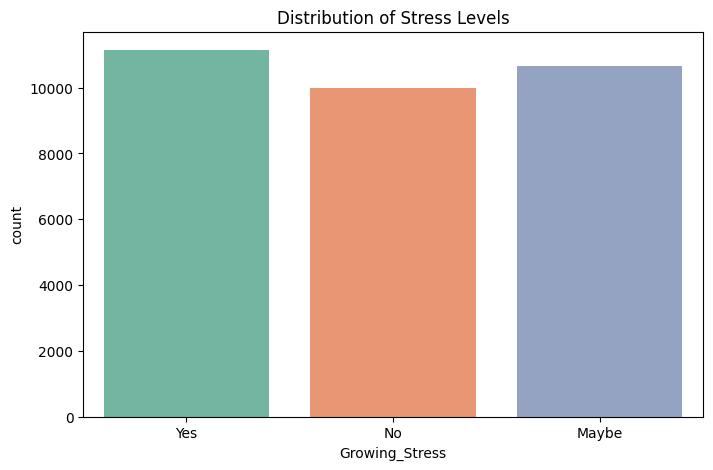

In [297]:
plt.figure(figsize=(8,5))
sns.countplot(x="Growing_Stress", data=df, palette="Set2")
plt.title("Distribution of Stress Levels")
plt.show()

### Gender vs Stress

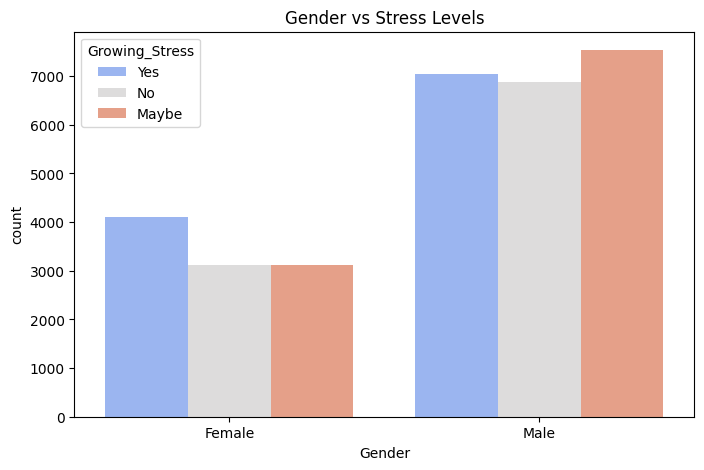

In [298]:
plt.figure(figsize=(8,5))
sns.countplot(x="Gender", hue="Growing_Stress", data=df, palette="coolwarm")
plt.title("Gender vs Stress Levels")
plt.show()

### Occupation vs Stress

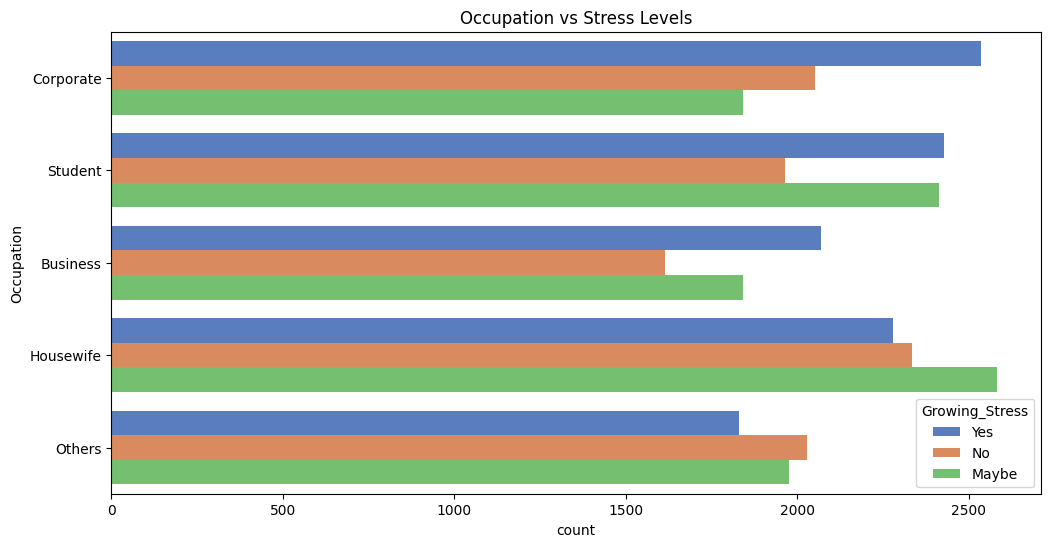

In [299]:
plt.figure(figsize=(12,6))
sns.countplot(y="Occupation", hue="Growing_Stress", data=df, palette="muted")
plt.title("Occupation vs Stress Levels")
plt.show()

### Mood Swings Distribution

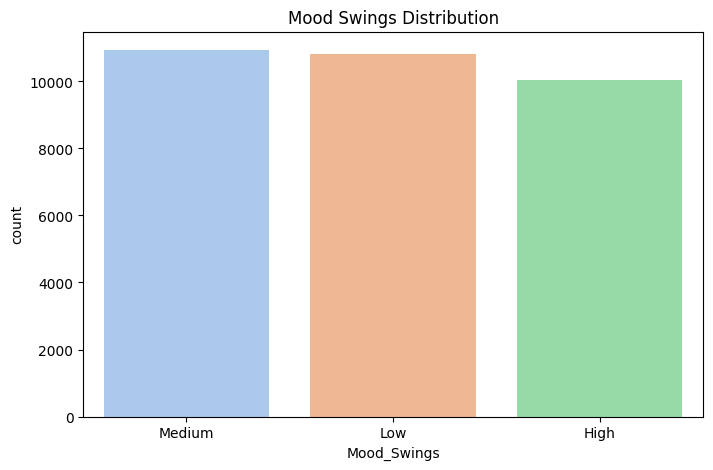

In [300]:
plt.figure(figsize=(8,5))
sns.countplot(x="Mood_Swings", data=df, palette="pastel")
plt.title("Mood Swings Distribution")
plt.show()

### Days Indoors vs Stress

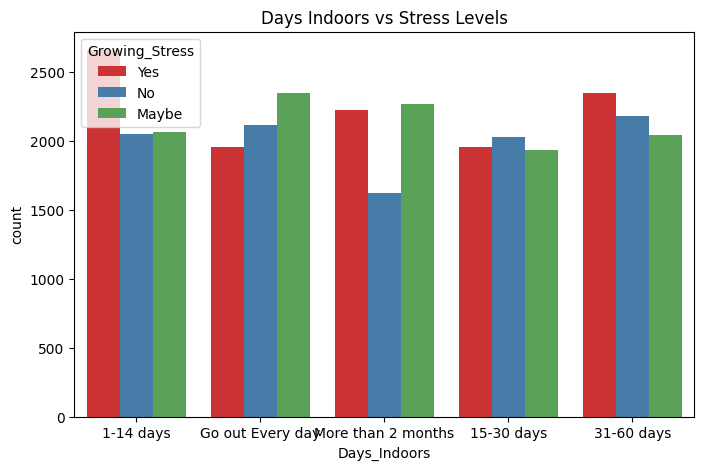

In [301]:
plt.figure(figsize=(8,5))
sns.countplot(x="Days_Indoors", hue="Growing_Stress", data=df, palette="Set1")
plt.title("Days Indoors vs Stress Levels")
plt.show()

### Days Indoors vs Stress (Boxplot)

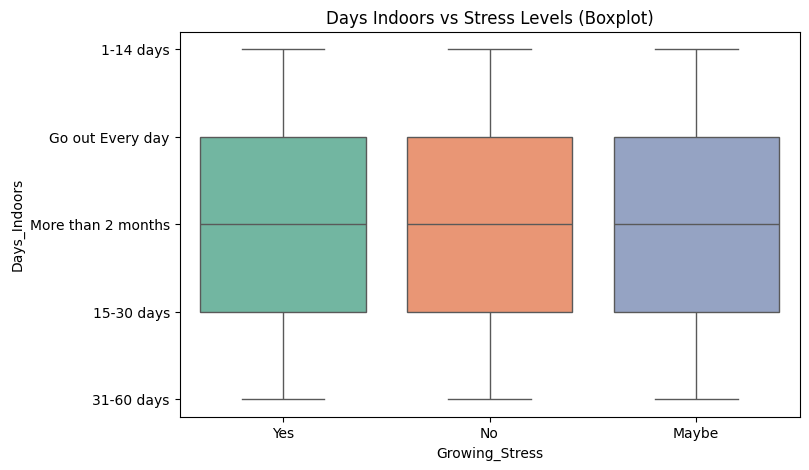

In [302]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Growing_Stress", y="Days_Indoors", data=df, palette="Set2")
plt.title("Days Indoors vs Stress Levels (Boxplot)")
plt.show()

### Occupation vs Stress (Boxplot)

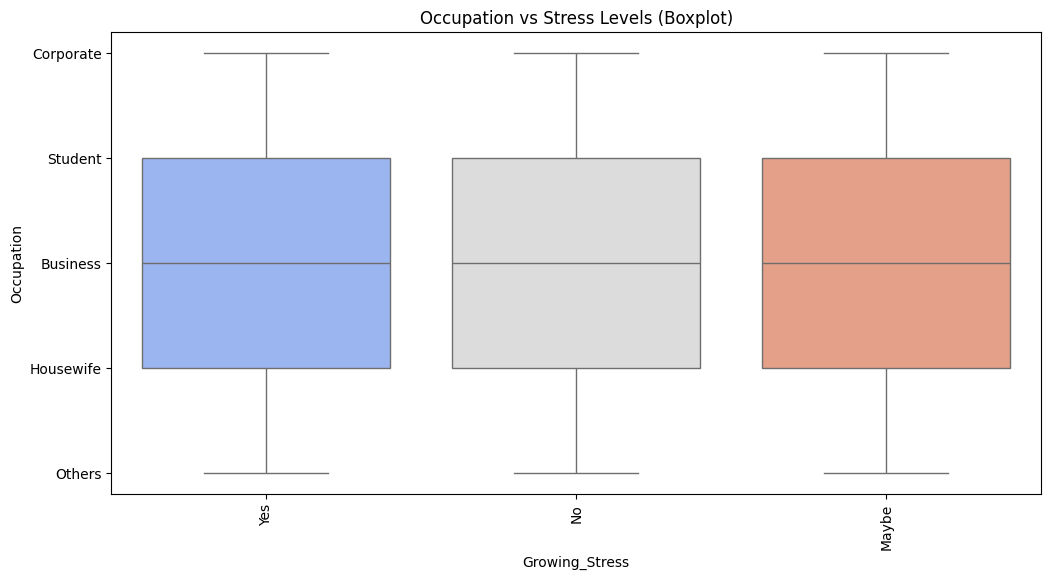

In [303]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Growing_Stress", y="Occupation", data=df, palette="coolwarm")
plt.title("Occupation vs Stress Levels (Boxplot)")
plt.xticks(rotation=90)
plt.show()

### Mood Swings vs Stress (Boxplot)

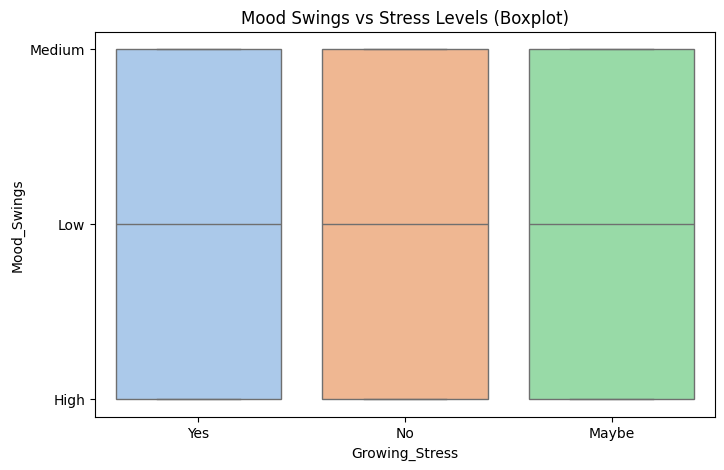

In [304]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Growing_Stress", y="Mood_Swings", data=df, palette="pastel")
plt.title("Mood Swings vs Stress Levels (Boxplot)")
plt.show()

## Encode Categorical Variables

### Label Encoding

In [305]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [306]:
# Encode categorical features
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [307]:
df.head()

,Gender,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,0,1,0,0,1,0,2,1,2,2,0,1,2,1,1
1,0,1,0,1,1,0,2,1,2,2,0,1,2,1,0
2,0,1,0,1,1,0,2,1,2,2,0,1,2,1,2
3,0,1,0,1,1,0,2,1,2,2,0,1,2,0,2
5,0,1,0,0,1,0,2,1,2,2,0,1,2,0,1


In [308]:
df['Growing_Stress'].value_counts()

Growing_Stress
2    11144
0    10655
1     9995
Name: count, dtype: int64

In [309]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31794 entries, 0 to 292339
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Gender                   31794 non-null  int64
 1   Occupation               31794 non-null  int64
 2   self_employed            31794 non-null  int64
 3   family_history           31794 non-null  int64
 4   treatment                31794 non-null  int64
 5   Days_Indoors             31794 non-null  int64
 6   Growing_Stress           31794 non-null  int64
 7   Changes_Habits           31794 non-null  int64
 8   Mental_Health_History    31794 non-null  int64
 9   Mood_Swings              31794 non-null  int64
 10  Coping_Struggles         31794 non-null  int64
 11  Work_Interest            31794 non-null  int64
 12  Social_Weakness          31794 non-null  int64
 13  mental_health_interview  31794 non-null  int64
 14  care_options             31794 non-null  int64
dtypes: int

### Correlation Heatmap

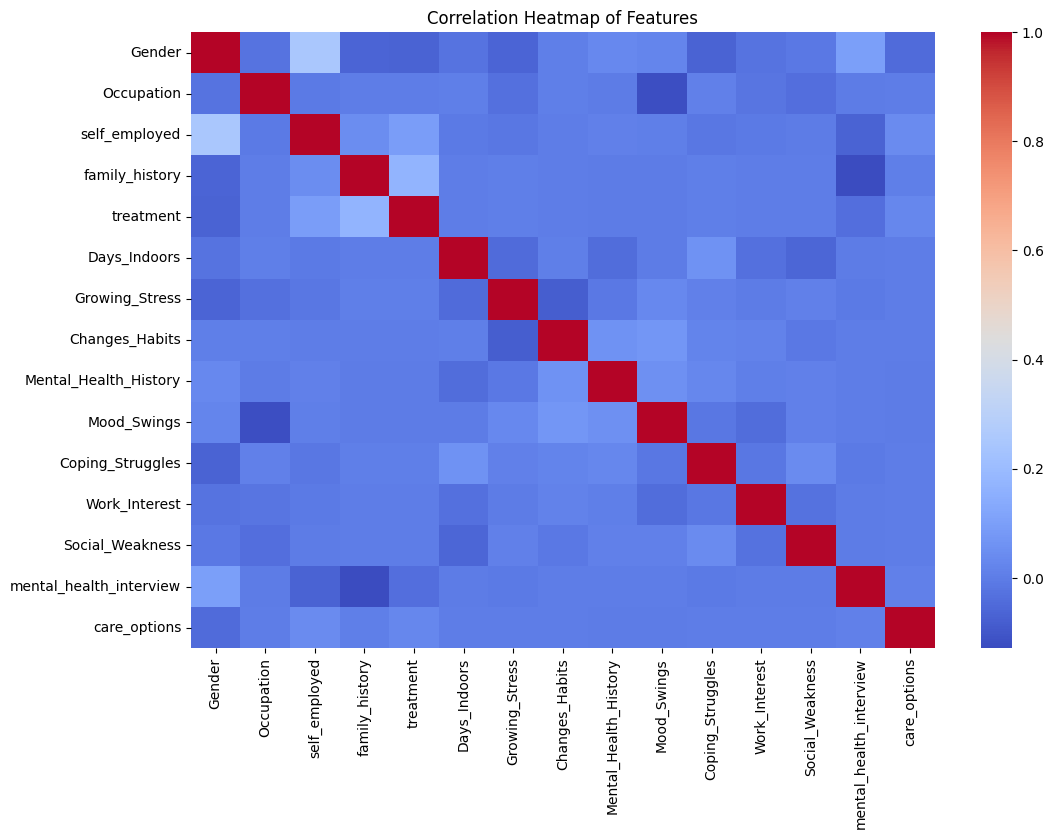

In [310]:
# Select only numeric columns
df_numeric = df.select_dtypes(include=['int64','float64'])

# Correlation matrix
df_corr = df_numeric.corr()

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap of Features")
plt.show()

## Features and Targets

In [311]:
X = df.drop("Growing_Stress", axis=1)

y = df["Growing_Stress"]

## Train Test Split

In [312]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Feature Scaling

In [313]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Machine Learning Models Training

### Decision Tree Model

In [314]:
dt = DecisionTreeClassifier(random_state=42)

In [315]:
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [316]:
y_pred_dt = dt.predict(X_test)

In [317]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9831734549457462


In [318]:
from sklearn.metrics import classification_report

In [319]:
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2129
           1       0.98      0.99      0.99      1948
           2       0.98      0.97      0.98      2282

    accuracy                           0.98      6359
   macro avg       0.98      0.98      0.98      6359
weighted avg       0.98      0.98      0.98      6359



In [320]:
# Prediction on new data
new_data=np.array([[0,4,0,0,0,2,0,0,2,1,2,1,1,1]])

# Predict class
prediction = dt.predict(new_data)

print("Predicted Class:", prediction)


Predicted Class: [1]


### XG Boost Model

In [321]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [322]:
import xgboost as xgb

In [353]:
model = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=3,                 # number of classes (Yes, No, Maybe)
    eval_metric='mlogloss',      # evaluation metric
    use_label_encoder=False,
    random_state=42
)

In [354]:
# Train model
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [355]:
# Predict
y_pred = model.predict(X_test)

In [356]:
# Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[2109    0   20]
 [   0 1937   11]
 [  35   29 2218]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      2129
           1       0.99      0.99      0.99      1948
           2       0.99      0.97      0.98      2282

    accuracy                           0.99      6359
   macro avg       0.99      0.99      0.99      6359
weighted avg       0.99      0.99      0.99      6359



In [357]:
# Prediction on new data
new_data=np.array([[0,0,0,0,0,4,0,1,2,1,2,1,0,0]])


# Predict class
prediction = model.predict(new_data)

print("Predicted Class:", prediction)

Predicted Class: [1]


## Model Comparison

In [328]:
results = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "XG Boost"
    ],

    "Accuracy":[
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred)
    ]
})

print(results)

           Model  Accuracy
0  Decision Tree  0.983173
1       XG Boost  0.985061


### Confusion Matrix

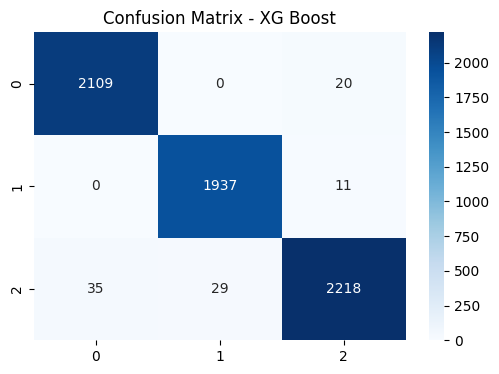

In [329]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XG Boost")
plt.show()

## Deep Learning Model

### Artificial Neural Network

In [330]:
model = Sequential()

# Input layer + hidden layer
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Second hidden layer
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Output layer (softmax for multi-class classification)
model.add(Dense(len(np.unique(y)), activation='softmax'))

In [331]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [332]:
# Early stopping to avoid overfitting
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[es])

Epoch 1/50
795/795 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3736 - loss: 1.1919 - val_accuracy: 0.4483 - val_loss: 1.0545
Epoch 2/50
795/795 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4153 - loss: 1.0762 - val_accuracy: 0.4774 - val_loss: 1.0365
Epoch 3/50
795/795 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4439 - loss: 1.0505 - val_accuracy: 0.4969 - val_loss: 1.0048
Epoch 4/50
795/795 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4739 - loss: 1.0254 - val_accuracy: 0.5543 - val_loss: 0.9544
Epoch 5/50
795/795 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5086 - loss: 0.9912 - val_accuracy: 0.6050 - val_loss: 0.8929
Epoch 6/50
795/795 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5314 - loss: 0.9602 - val_accuracy: 0.6448 - val_loss: 0.8376
Epoch 7/50
795/795 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5618 - loss: 0.9219 - val_accuracy: 0.6889 - val_loss: 0.7781
Epoch 8/50
795/795 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5807 - loss: 0.8956 - val_accuracy: 0.

In [333]:
loss, acc = model.evaluate(X_test, y_test)
print("Deep Learning Model Accuracy:", acc)

199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9047 - loss: 0.3683
Deep Learning Model Accuracy: 0.9047020077705383


In [334]:
dl_predictions = model.predict(X_test)

print(dl_predictions[:5])

199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[0.9482969  0.04783418 0.00386883]
 [0.91867423 0.07483093 0.00649486]
 [0.8450061  0.01791314 0.13708071]
 [0.04056264 0.04809085 0.9113465 ]
 [0.07673874 0.07323878 0.85002244]]


In [335]:
dl_pred_classes = np.argmax(dl_predictions, axis=1)

print(dl_pred_classes[:10])

[0 0 0 2 2 2 2 0 0 2]


In [336]:
from sklearn.metrics import accuracy_score

dl_accuracy = accuracy_score(y_test, dl_pred_classes)

print("Deep Learning Accuracy:", dl_accuracy)

Deep Learning Accuracy: 0.9047019971693663


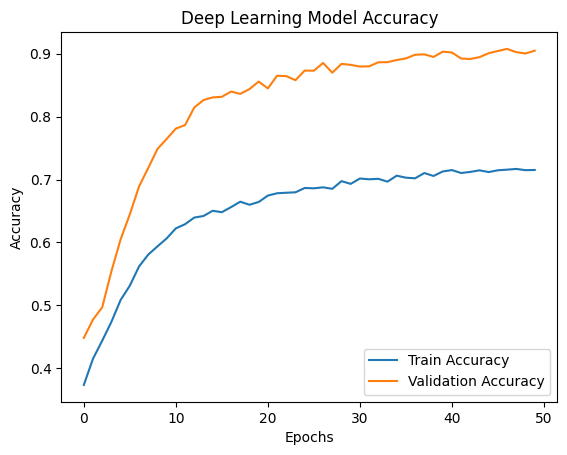

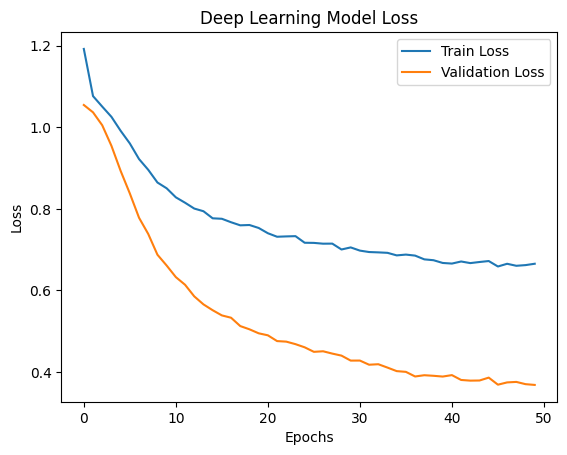

In [337]:
# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Deep Learning Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Deep Learning Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [338]:
results_dl = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": dl_pred_classes

})

results_dl.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,2,2
4,2,2
5,2,2
6,2,2
7,2,0
8,0,0
9,2,2


## Models Accuracy Comparison

In [339]:
results = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "XG Boost",
        "Deep Learning(ANN)"
    ],

    "Accuracy":[
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test,dl_pred_classes)
    ]
})

print(results)

                Model  Accuracy
0       Decision Tree  0.983173
1            XG Boost  0.985061
2  Deep Learning(ANN)  0.904702


### Model Saving

In [342]:
import pickle
# Save model
pickle.dump(model, open("model.pkl", "wb"))

# Save features list
pickle.dump(X.columns.tolist(), open("features.pkl", "wb"))

# Save scaler if you used scaling
pickle.dump(scaler, open("scaler.pkl", "wb"))